TODO clean this up a little bit and make a training set 
1. check size of xyz files, decide if going to save the files or just make on the fly (save at first I'd think)
2. make training set 

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import ndimage as ndi
from ase import io as aio
import abtem

from gas.PDFs.RDFs import RDF
from gas.PDFs.RDF_2D import RDF_2D
from gas.PDFs.PDF_3body import PDF3B
from gas.PDFs.PDFs_utils.PDF_show import plot_RDF3b, plot_r1r2_RDF3b
from gas.io.xyz import load_xyz
from datetime import datetime 


try:
    import cupy as cp
    if cp.cuda.is_available():
        print(f"Found {cp.cuda.runtime.getDeviceCount()} GPUs")
        device = 1
        print(f"Will use GPU {device}")
        cp.cuda.Device(device).use()
    else:
        print("No GPUs found, using CPU")
        device='cpu'
except (ImportError, ModuleNotFoundError):
    print("No GPUs found, using CgPU")
    device='cpu'

In [ ]:

tdir = Path("~/data/distillery/structures/Al2O3/3_90_overlap/").expanduser()

init_file = next(tdir.glob("*initial.xyz"))
relax_file = next(tdir.glob("*relaxed.xyz"))
quench_file = next(tdir.glob("*quenched.xyz"))

init_file


# Downloading structures from materials project

In [ ]:
from mp_api.client import MPRester
from pymatgen.io.cif import CifWriter

mp_code = "mp-1143"

with MPRester(api_key="qLBVwWWckIrrZoY4Eklu3cVggHJ79lOC") as mpr:
    mat_data = mpr.materials.search(material_ids=[mp_code])[0]
    # print(mat_data)

mat_name = mat_data.formula_pretty
outdir = Path(f"~/data/distillery/structures/{mat_name}").expanduser()
outfile = outdir / f"{mat_name}_{str(mat_data.symmetry.crystal_system).lower()}_{mp_code}.cif"
print(outfile)
assert outdir.exists() 
w = CifWriter(mat_data.structure)
w.write_file(outfile)

# Gaussian noise for each atom

In [ ]:
RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}

rdf = RDF(device=device, v=0)
fig, ax = plt.subplots()

gr_3Ds = {}

for f, nm in zip([init_file, relax_file, quench_file], ["init", "relax", "quench"]): 
    atoms = load_xyz(f, v=0)
    
    r, gr_3D = rdf.rdf(
        atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
    )
    r = r.get()
    gr_3D=gr_3D.get()
    gr_3Ds[nm] = gr_3D
    gr_3Ds['r'] = r

    ax.plot(r, gr_3D, label=f.stem)
    
ax.legend() 
plt.show()
    

In [ ]:
RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}

# sigmas = [0.01, 0.02, 0.03]
sigmas = [0.05, 0.1, 0.2]
# sigmas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

gr_3Dsigmas = {}

rdf = RDF(device=device, v=3)
# atoms2 = load_xyz(init_file, v=3) 
atoms2 = load_xyz(quench_file, v=3) 
for sigma in tqdm(sigmas):
    jitter = np.random.normal(loc=0, scale=sigma, size=atoms2.positions.shape)
    atoms2.positions += jitter
    atoms2.wrap() 

    rs, gr_3D_sigma = rdf.rdf(
        atoms2,
        pbcs=atoms2.pbc,
        **RDF_params, 
    )
    gr_3D_sigma = gr_3D_sigma.get()
    gr_3Dsigmas[f"gr_sigma_{sigma}"] = gr_3D_sigma 

gr_3Dsigmas['r'] = rs.get() 
fig, ax = plt.subplots()
# ax.plot(r, gr_3Dsigmas['init'], label='no jitter')

for sigma in sigmas: 
    ax.plot(gr_3Dsigmas['r'], gr_3Dsigmas[f"gr_sigma_{sigma}"], label=f'sigma {sigma}', lw = 2)
ax.legend()
ax.set_title(init_file.stem)
plt.show()
    

In [ ]:
fig, ax = plt.subplots()
ax.plot(gr_3Ds['r'], gr_3Ds['init']+8, label='initial')
ax.plot(gr_3Ds['r'], gr_3Ds['quench']+5, label='quench')
# ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.01']+3, label='sigma 0.01')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.05']+2, label='sigma 0.05')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.1']+0, label='sigma 0.1')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.2']-1, label='sigma 0.2')
ax.legend()
ax.set_title(f"Quenched vs initial+jitter | {quench_file.stem}")
ax.set_ylabel("g(r)")
ax.set_xlabel("r (A)")
plt.show()


# Improved orientation mixing with rotations and such 
- use init file
- rotation of random blocks
- BZA spline + vortex operations or gaussians, + normalization 
    - long range variation in displacement 
- last pass do a repulsion check 

loading file: Al2O3_3_90_overlap_initial.xyz
# atoms: 199560
Atoms(symbols='Al79799O119761', pbc=True, cell=[85.50786007169349, 87.11991157790018, 219.68091918519644])
Cell size (A): [ 85.50786007  87.11991158 219.68091919]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5
Reducing dr_ind from 0.5 -> 0.25
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.122 atoms / A^3
N_max_neighbors:  10344
-- done --
Total time (h:m:s) 0:00:02.387
Center atoms per sec: 836.15



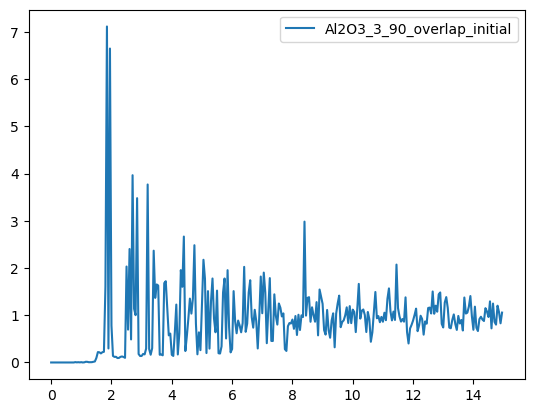

In [574]:
# f = next(tdir.glob("../*crystal.xyz"))
# f = relax_file
# f = quench_file
f = init_file
# f = Path("~/data/distillery/structures/SiO2/nc_seeds/SiO2_nc_10_initial.xyz").expanduser()
# f = Path("~/data/distillery/structures/SiO2/SiO2_amorphous.xyz").expanduser()
atoms = load_xyz(f, v=1)

RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}
rdf = RDF(device=device, v=1)
r, gr_init = rdf.rdf(
        atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
)
gr_init = gr_init.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label=f.stem)
ax.legend() 
plt.show()
    

  0%|          | 0/10 [00:00<?, ?it/s]

pushing atoms:   7%|▋         | 7/100 [00:03<00:48,  1.92it/s]

Done
Num atoms 199560/199560 = 100.0%
Cell size (A): [ 85.50786007  87.11991158 219.68091919]
Using a max radius of 15 A
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.122 atoms / A^3
N_max_neighbors:  10344
-- done --
Total time (h:m:s) 0:00:00.038
Center atoms per sec: 52_139.81



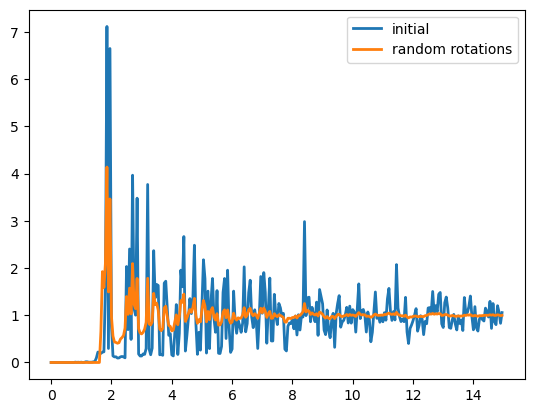

In [575]:
from gas.generation.modify_volume import modify_volume, remove_close_atoms, push_close_atoms
rng = np.random.default_rng(42)

config = {
    "N_iterations": 10, 
    "N_points_per_iter": 15, 
    "radius": 20, 
    "seeds_frac": 1, # 
    "theta_max": 10, 
    "region_type": "sphere", 
    "_pick_point_max": 1000,
    "threshold": 0.9 * r[np.argmax(gr_init)], 
    "gaussian_sigma": 0.0, 
}

mod_atoms = modify_volume(
    atoms, 
    config, 
    rng, 
)

print(f"Num atoms {len(mod_atoms)}/{len(atoms)} = {len(mod_atoms)/len(atoms)*100:.1f}%")
r, gr2 = rdf.rdf(
        mod_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr2 = gr2.get()
r = r.get()
fig, ax = plt.subplots()
ax.plot(r, gr_init, label='initial', lw=2)
ax.plot(r, gr2, label='random rotations', lw=2)
ax.legend() 
plt.show()

pushing atoms:   9%|▉         | 9/100 [00:04<00:49,  1.83it/s]

Done
Num atoms 199560/199560 = 100.0%
Cell size (A): [ 85.50786007  87.11991158 219.68091919]
Using a max radius of 15 A
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.122 atoms / A^3
N_max_neighbors:  10344
-- done --
Total time (h:m:s) 0:00:00.038
Center atoms per sec: 52_030.54



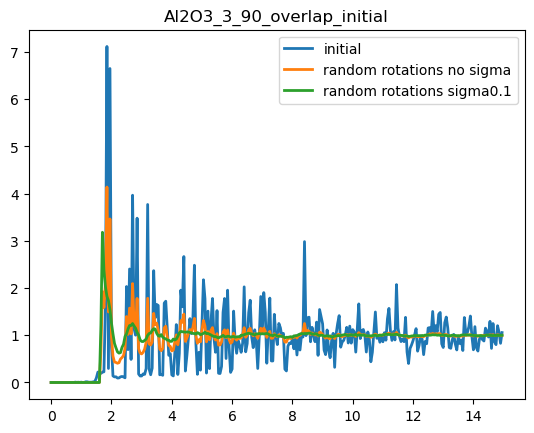

In [576]:
rng = np.random.default_rng(42)

config = {
    "N_iterations": 10, 
    "N_points_per_iter": 15, 
    "radius": 20, 
    "seeds_frac": 1, # 
    "theta_max": 10, 
    "region_type": "sphere", 
    "_pick_point_max": 1000,
    "threshold": 0.9 * r[np.argmax(gr_init)], 
    "gaussian_sigma": 0.1, 
}

mod_atoms2 = modify_volume(
    atoms, 
    config, 
    rng, 
)

print(f"Num atoms {len(mod_atoms2)}/{len(atoms)} = {len(mod_atoms2)/len(atoms)*100:.1f}%")
r, gr3 = rdf.rdf(
        mod_atoms2,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr3 = gr3.get()
r = r.get()
fig, ax = plt.subplots()
ax.plot(r, gr_init, label='initial', lw=2)
ax.plot(r, gr2, label='random rotations no sigma', lw=2)
ax.plot(r, gr3, label=f'random rotations sigma{config['gaussian_sigma']}', lw=2)
ax.set_title(f.stem)
ax.legend() 
plt.show()

pushing atoms:   8%|▊         | 8/100 [00:04<00:49,  1.86it/s]

Done
Num atoms 199560/199560 = 100.0%
Cell size (A): [ 85.50786007  87.11991158 219.68091919]
Using a max radius of 15 A
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.122 atoms / A^3
N_max_neighbors:  10344
-- done --
Total time (h:m:s) 0:00:00.038
Center atoms per sec: 51_967.39



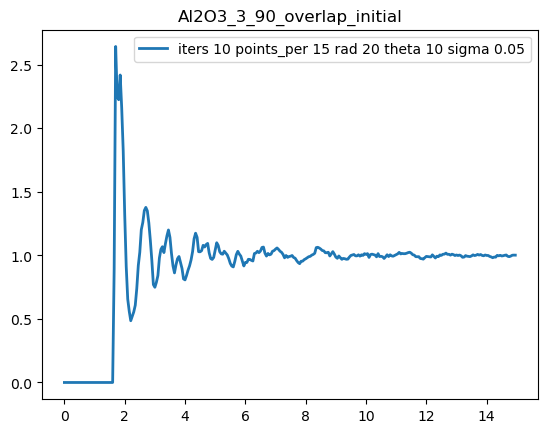

In [592]:
rng = np.random.default_rng(42)

config = {
    "N_iterations": 10, 
    "N_points_per_iter": 15, 
    "radius": 20, 
    "seeds_frac": 1, # 
    "theta_max": 10, 
    "region_type": "sphere", 
    "_pick_point_max": 1000,
    "threshold": 0.9 * r[np.argmax(gr_init)], 
    "gaussian_sigma": 0.05, 
}

mod_atoms2 = modify_volume(
    atoms, 
    config, 
    rng, 
)

print(f"Num atoms {len(mod_atoms2)}/{len(atoms)} = {len(mod_atoms2)/len(atoms)*100:.1f}%")
r, gr3 = rdf.rdf(
        mod_atoms2,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr3 = gr3.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr3, label=f'iters {config['N_iterations']} points_per {config['N_points_per_iter']} rad {config['radius']} theta {config['theta_max']} sigma {config['gaussian_sigma']}', lw=2)
ax.set_title(f.stem)
ax.legend() 
plt.show()